In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("bank-full.csv")
print("Dataset loaded successfully")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully
Shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df["subscribed"] = df["y"].map({"yes": 1, "no": 0})
month_order = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]
df["month"] = pd.Categorical(
    df["month"],
    categories=month_order,
    ordered=True
)
print(df[["month", "y", "subscribed"]].head())

  month   y  subscribed
0   may  no           0
1   may  no           0
2   may  no           0
3   may  no           0
4   may  no           0


In [4]:
monthly_forecast = (
    df.groupby("month", observed=True)["subscribed"]
      .mean()
      .reset_index()
)
monthly_forecast["subscription_rate"] = (
    monthly_forecast["subscribed"] * 100
)
monthly_forecast

,month,subscribed,subscription_rate
0,jan,0.101212,10.121169
1,feb,0.166478,16.647792
2,mar,0.519916,51.991614
3,apr,0.196794,19.679400
4,may,0.067195,6.719454
5,jun,0.102228,10.222805
6,jul,0.090935,9.093546
7,aug,0.110133,11.013286
8,sep,0.464594,46.459413
9,oct,0.437669,43.766938


In [5]:
monthly_forecast["moving_average"] = (
    monthly_forecast["subscription_rate"]
    .rolling(window=3)
    .mean()
)
monthly_forecast

,month,subscribed,subscription_rate,moving_average
0,jan,0.101212,10.121169,NaN
1,feb,0.166478,16.647792,NaN
2,mar,0.519916,51.991614,26.253525
3,apr,0.196794,19.679400,29.439602
4,may,0.067195,6.719454,26.130156
5,jun,0.102228,10.222805,12.207219
6,jul,0.090935,9.093546,8.678601
7,aug,0.110133,11.013286,10.109879
8,sep,0.464594,46.459413,22.188748
9,oct,0.437669,43.766938,33.746546


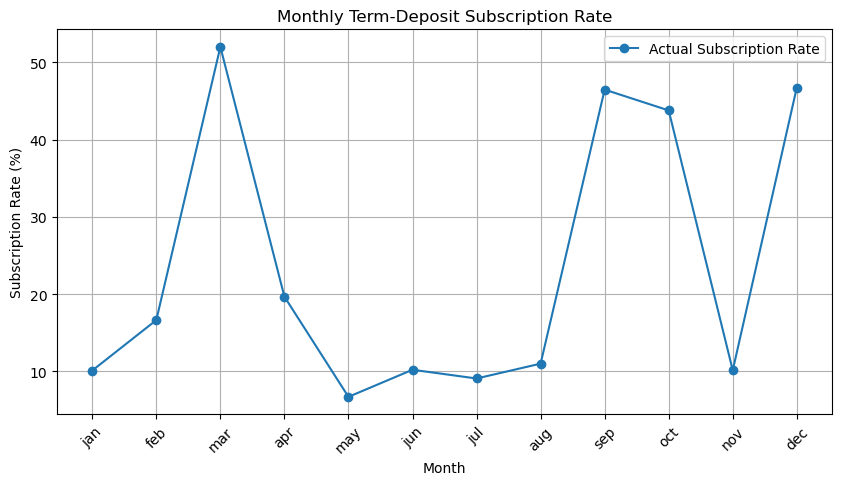

In [6]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_forecast["month"].astype(str),
    monthly_forecast["subscription_rate"],
    marker="o",
    label="Actual Subscription Rate"
)
plt.title("Monthly Term-Deposit Subscription Rate")
plt.xlabel("Month")
plt.ylabel("Subscription Rate (%)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [7]:
last_three = monthly_forecast["subscription_rate"].tail(3)

forecast_value = last_three.mean()

future_months = ["Next Month", "Month +2", "Month +3"]

forecast_df = pd.DataFrame({
    "Period": future_months,
    "Forecasted Subscription Rate (%)": [forecast_value] * 3
})

forecast_df

,Period,Forecasted Subscription Rate (%)
0,Next Month,33.549014
1,Month +2,33.549014
2,Month +3,33.549014


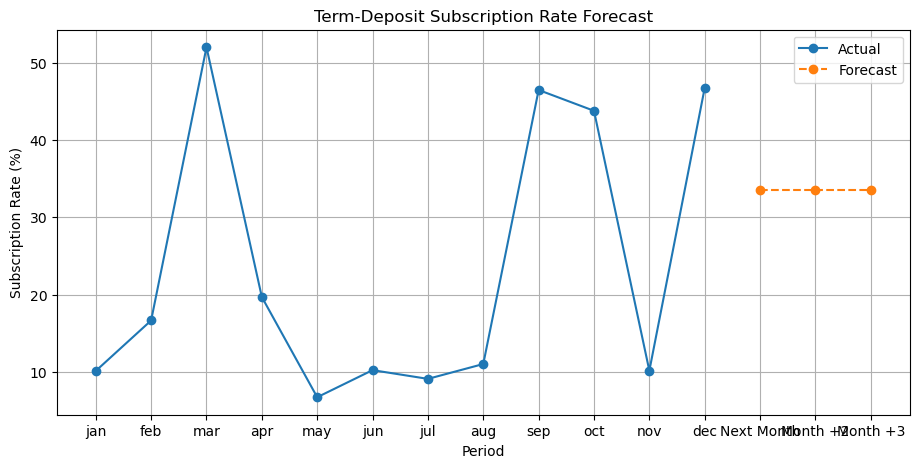

In [8]:
plt.figure(figsize=(11, 5))
plt.plot(
    monthly_forecast["month"].astype(str),
    monthly_forecast["subscription_rate"],
    marker="o",
    label="Actual"
)
plt.plot(
    future_months,
    forecast_df["Forecasted Subscription Rate (%)"],
    marker="o",
    linestyle="--",
    label="Forecast"
)
plt.title("Term-Deposit Subscription Rate Forecast")
plt.xlabel("Period")
plt.ylabel("Subscription Rate (%)")
plt.legend()
plt.grid(True)

plt.show()

In [9]:
average_historical = monthly_forecast["subscription_rate"].mean()

forecast_rate = forecast_df[
    "Forecasted Subscription Rate (%)"
].iloc[0]

difference = forecast_rate - average_historical

print("Average historical subscription rate:",
      round(average_historical, 2), "%")

print("Forecasted subscription rate:",
      round(forecast_rate, 2), "%")

print("Difference from historical average:",
      round(difference, 2), "percentage points")

Average historical subscription rate: 23.55 %
Forecasted subscription rate: 33.55 %
Difference from historical average: 10.0 percentage points


In [10]:
rates = monthly_forecast["subscription_rate"].values

actual_last = rates[-1]

predicted_last = np.mean(rates[-4:-1])

mae = abs(actual_last - predicted_last)

print("Actual last-month subscription rate:",
      round(actual_last, 2), "%")

print("Predicted last-month subscription rate:",
      round(predicted_last, 2), "%")

print("Mean Absolute Error (MAE):",
      round(mae, 2), "percentage points")

Actual last-month subscription rate: 46.73 %
Predicted last-month subscription rate: 33.46 %
Mean Absolute Error (MAE): 13.27 percentage points


In [11]:
print("FINAL FORECAST")
print("=" * 45)

for _, row in forecast_df.iterrows():
    print(
        row["Period"],
        ":",
        round(row["Forecasted Subscription Rate (%)"], 2),
        "%"
    )

FINAL FORECAST
Next Month : 33.55 %
Month +2 : 33.55 %
Month +3 : 33.55 %
